
===== Linear Regression =====
R2: 0.9109
RMSE: 6.1335

===== Support Vector Machine =====
R2: 0.7907
RMSE: 9.4028

===== KNN Regressor =====
R2: 0.8029
RMSE: 9.1249

===== PCA Analysis =====
Explained Variance Ratio: [0.14100638 0.13456284]
Total Variance Explained by 2 Components: 27.56 %


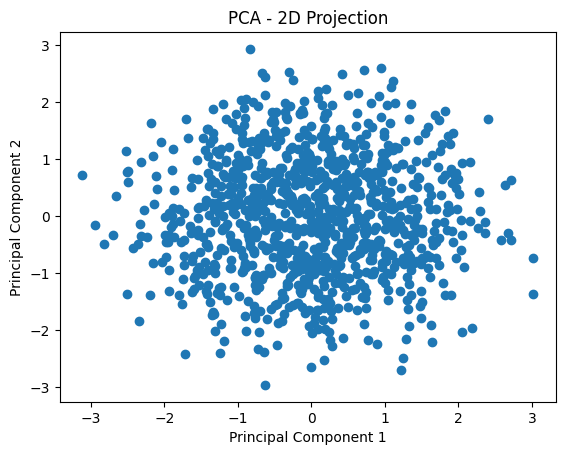

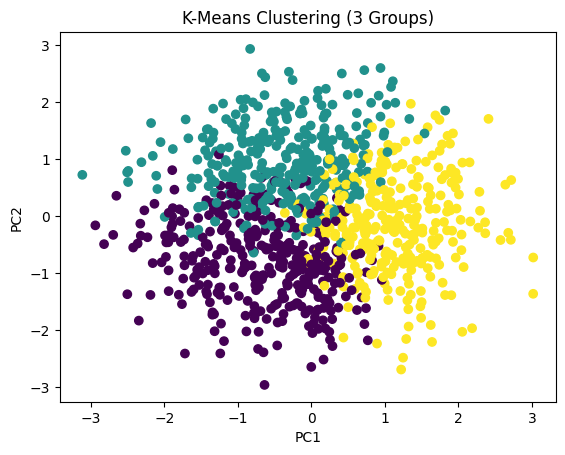


===== K-Means =====
Cluster centers identified for 3 warehouse workload types.


In [1]:
# ===============================================
# ADVANCED MACHINE LEARNING ON WAREHOUSE DATASET
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# 1️⃣ Load Dataset
data = pd.read_csv(r"C:\Users\drisy\Downloads\warehouse_order_processing.csv")

X = data.drop("Order_Processing_Time_min", axis=1)
y = data["Order_Processing_Time_min"]

# Scaling (important for SVM, KNN, PCA, KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# =====================================================
# 1️⃣ Linear Regression
# =====================================================
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\n===== Linear Regression =====")
print("R2:", round(r2_score(y_test, y_pred_lr),4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_lr)),4))


# =====================================================
# 2️⃣ Support Vector Machine (SVR)
# =====================================================
svm = SVR(kernel='rbf')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("\n===== Support Vector Machine =====")
print("R2:", round(r2_score(y_test, y_pred_svm),4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_svm)),4))


# =====================================================
# 3️⃣ KNN Regressor
# =====================================================
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("\n===== KNN Regressor =====")
print("R2:", round(r2_score(y_test, y_pred_knn),4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_knn)),4))


# =====================================================
# 4️⃣ PCA (Dimensionality Reduction)
# =====================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\n===== PCA Analysis =====")
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained by 2 Components:",
      round(sum(pca.explained_variance_ratio_)*100,2), "%")

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA - 2D Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


# =====================================================
# 5️⃣ K-Means Clustering
# =====================================================
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("K-Means Clustering (3 Groups)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("\n===== K-Means =====")
print("Cluster centers identified for 3 warehouse workload types.")